<a href="https://colab.research.google.com/github/MilouSapinsky/codefinity-introduction-to-machine-learning-with-python/blob/master/EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassanali789/world-happiness-report-2026-official-rankings")

print("Path to dataset files:", path)

100%|██████████| 3.23k/3.23k [00:00<00:00, 5.39MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/hassanali789/world-happiness-report-2026-official-rankings/versions/2


In [3]:
import os
happy = pd.read_csv(os.path.join(path, 'world_happiness_2026 (3).csv'))
happy.head()

,rank,country,region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
0,1,Finland,Western Europe,7.764,1.892,1.581,0.952,0.670,0.186,0.498
1,2,Iceland,Western Europe,7.701,1.874,1.611,0.959,0.662,0.269,0.512
2,3,Denmark,Western Europe,7.688,1.887,1.562,0.948,0.665,0.211,0.495
3,4,Costa Rica,Latin America and Caribbean,7.439,1.254,1.421,0.891,0.631,0.178,0.312
4,5,Sweden,Western Europe,7.401,1.878,1.501,0.952,0.658,0.224,0.481


In [4]:
happy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rank                     130 non-null    int64  
 1   country                  130 non-null    object 
 2   region                   130 non-null    object 
 3   score                    130 non-null    float64
 4   gdp_per_capita           130 non-null    float64
 5   social_support           130 non-null    float64
 6   healthy_life_expectancy  130 non-null    float64
 7   freedom                  130 non-null    float64
 8   generosity               130 non-null    float64
 9   corruption               130 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 10.3+ KB


In [5]:
happy.tail()

,rank,country,region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
125,126,Central African Republic,Sub-Saharan Africa,3.441,0.171,0.691,0.341,0.261,0.131,0.011
126,127,South Sudan,Sub-Saharan Africa,3.421,0.361,0.691,0.341,0.221,0.171,0.011
127,128,Sierra Leone,Sub-Saharan Africa,3.401,0.351,0.741,0.371,0.311,0.201,0.021
128,129,Congo DR,Sub-Saharan Africa,2.761,0.191,0.601,0.311,0.201,0.141,0.011
129,130,Afghanistan,South Asia,1.446,0.241,0.341,0.361,0.071,0.071,0.011


In [6]:
happy.isnull().sum()

,0
rank,0
country,0
region,0
score,0
gdp_per_capita,0
social_support,0
healthy_life_expectancy,0
freedom,0
generosity,0
corruption,0


In [7]:
happy['country'].unique()

array(['Finland', 'Iceland', 'Denmark', 'Costa Rica', 'Sweden', 'Norway',
       'Netherlands', 'Israel', 'Luxembourg', 'Switzerland', 'Australia',
       'Mexico', 'New Zealand', 'Germany', 'Canada', 'Kosovo', 'Austria',
       'Belgium', 'Czechia', 'Slovenia', 'United Arab Emirates',
       'Saudi Arabia', 'United States', 'Ireland', 'United Kingdom',
       'Taiwan', 'France', 'Poland', 'Estonia', 'Lithuania', 'Slovakia',
       'Latvia', 'Spain', 'Italy', 'Romania', 'Serbia', 'Hungary',
       'Portugal', 'Greece', 'Singapore', 'Japan', 'South Korea',
       'Brazil', 'Argentina', 'Chile', 'Uruguay', 'China', 'Russia',
       'Malaysia', 'Thailand', 'Belarus', 'Colombia', 'Kazakhstan',
       'Ecuador', 'Panama', 'Paraguay', 'Peru', 'Bolivia', 'Nicaragua',
       'Vietnam', 'Philippines', 'Indonesia', 'Honduras', 'Mongolia',
       'Kyrgyzstan', 'Tajikistan', 'Morocco', 'India', 'Nepal',
       'Pakistan', 'Bangladesh', 'Sri Lanka', 'Myanmar', 'Cambodia',
       'Laos', 'Kenya', 'G

In [8]:
happy['region'].unique()

array(['Western Europe', 'Latin America and Caribbean',
       'Middle East and North Africa', 'North America and ANZ',
       'Central and Eastern Europe', 'East Asia', 'Southeast Asia',
       'Commonwealth of Independent States', 'South Asia',
       'Sub-Saharan Africa'], dtype=object)

In [9]:
happy_df = (happy[['rank', 'country', 'region', 'score', 'gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom', 'generosity', 'corruption']]).rename(columns={'region' : 'world_region', 'gdp_per_capita': 'gdp', 'social_support': 'support', 'healthy_life_expectancy': 'life_ex'})

In [10]:
happy_df.head()

,rank,country,world_region,score,gdp,support,life_ex,freedom,generosity,corruption
0,1,Finland,Western Europe,7.764,1.892,1.581,0.952,0.670,0.186,0.498
1,2,Iceland,Western Europe,7.701,1.874,1.611,0.959,0.662,0.269,0.512
2,3,Denmark,Western Europe,7.688,1.887,1.562,0.948,0.665,0.211,0.495
3,4,Costa Rica,Latin America and Caribbean,7.439,1.254,1.421,0.891,0.631,0.178,0.312
4,5,Sweden,Western Europe,7.401,1.878,1.501,0.952,0.658,0.224,0.481


In [11]:
numerical_cols_for_outliers = ['score', 'gdp', 'support', 'life_ex', 'freedom', 'generosity', 'corruption']
outliers_data = {}

for col in numerical_cols_for_outliers:
    Q1 = happy_df[col].quantile(0.25)
    Q3 = happy_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers = happy_df[(happy_df[col] < lower_bound) | (happy_df[col] > upper_bound)]

    outliers_data[col] = {"count": len(outliers), "values": outliers[[col, 'country', 'world_region']]}

    print(f"\n--- Outliers for '{col.replace('_', ' ').title()}' ---")
    print(f"Number of outliers: {len(outliers)}")
    if not outliers.empty:
        display(outliers[[col, 'country', 'world_region']])

print("\nSummary of Outliers:")
for col, data in outliers_data.items():
    print(f"'{col.replace('_', ' ').title()}': {data['count']} outliers")


--- Outliers for 'Score' ---
Number of outliers: 0

--- Outliers for 'Gdp' ---
Number of outliers: 0

--- Outliers for 'Support' ---
Number of outliers: 0

--- Outliers for 'Life Ex' ---
Number of outliers: 0

--- Outliers for 'Freedom' ---
Number of outliers: 1


,freedom,country,world_region
129,0.071,Afghanistan,South Asia



--- Outliers for 'Generosity' ---
Number of outliers: 0

--- Outliers for 'Corruption' ---
Number of outliers: 0

Summary of Outliers:
'Score': 0 outliers
'Gdp': 0 outliers
'Support': 0 outliers
'Life Ex': 0 outliers
'Freedom': 1 outliers
'Generosity': 0 outliers
'Corruption': 0 outliers


Correlation between 'score' and 'gdp': 0.88


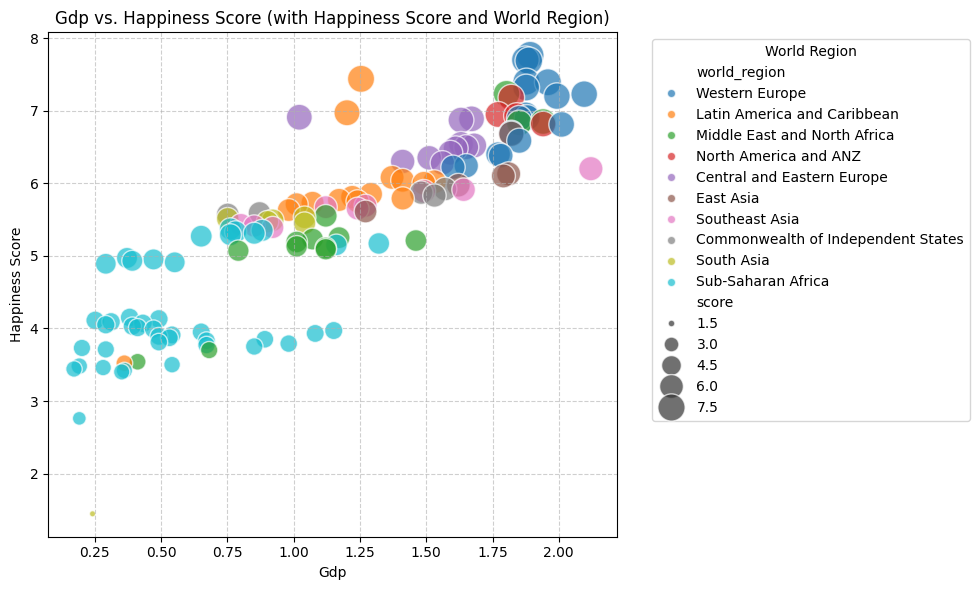

Correlation between 'score' and 'support': 0.98


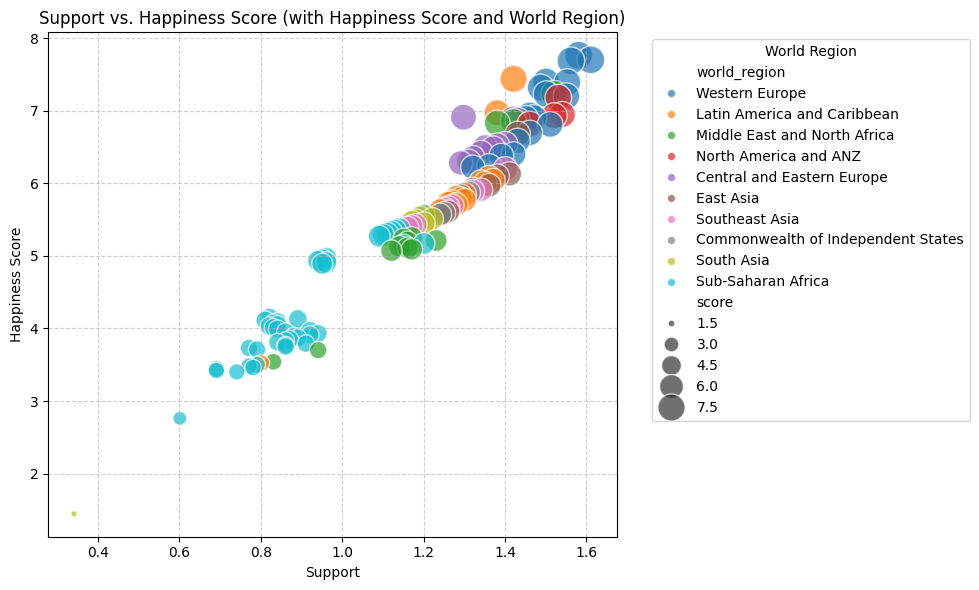

Correlation between 'score' and 'life_ex': 0.90


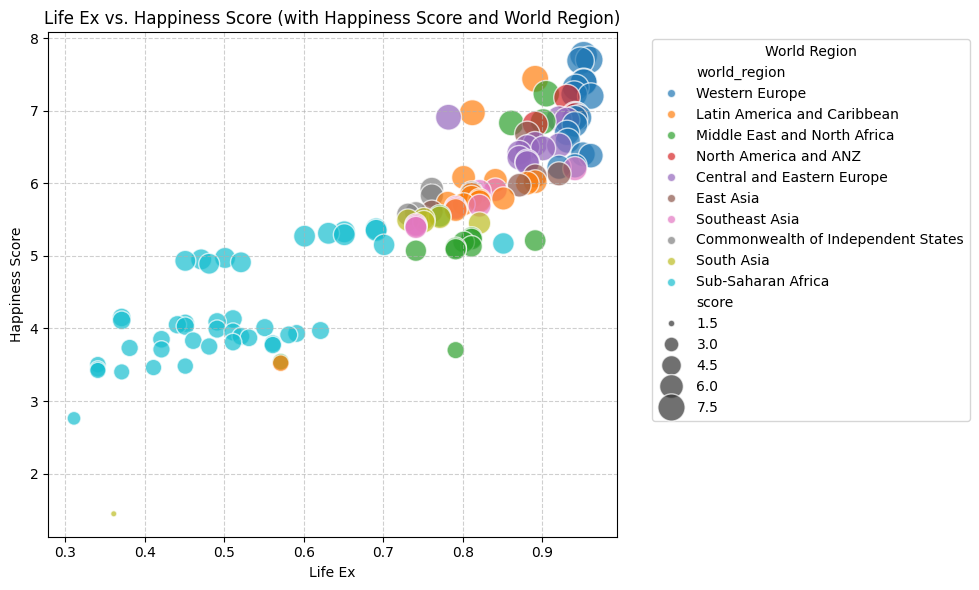

Correlation between 'score' and 'freedom': 0.93


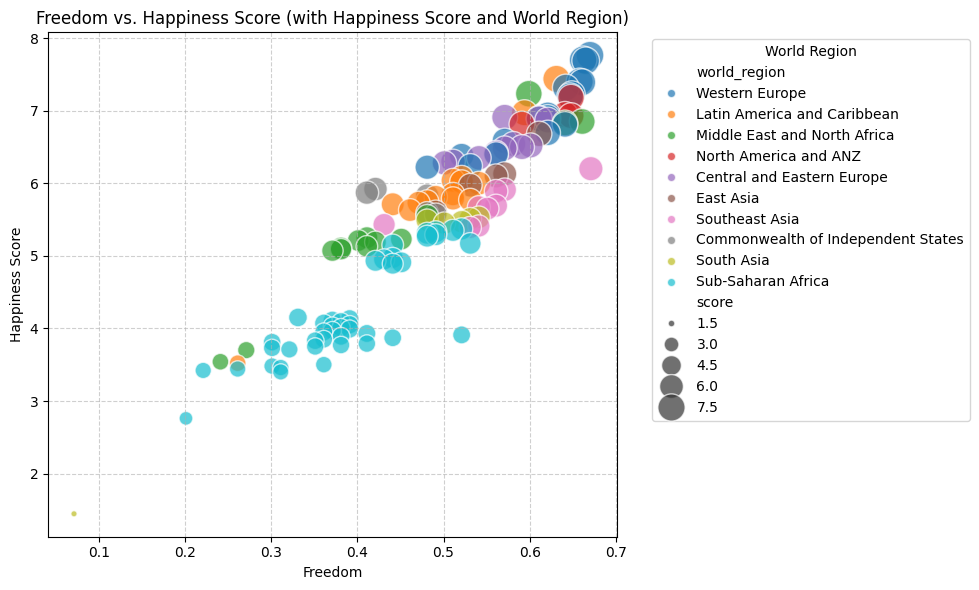

Correlation between 'score' and 'generosity': 0.24


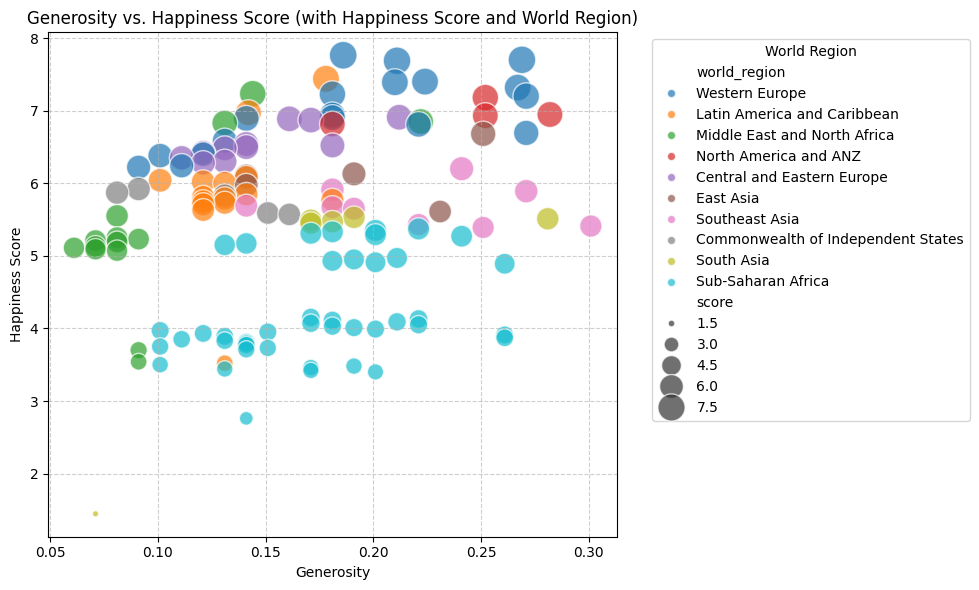

Correlation between 'score' and 'corruption': 0.87


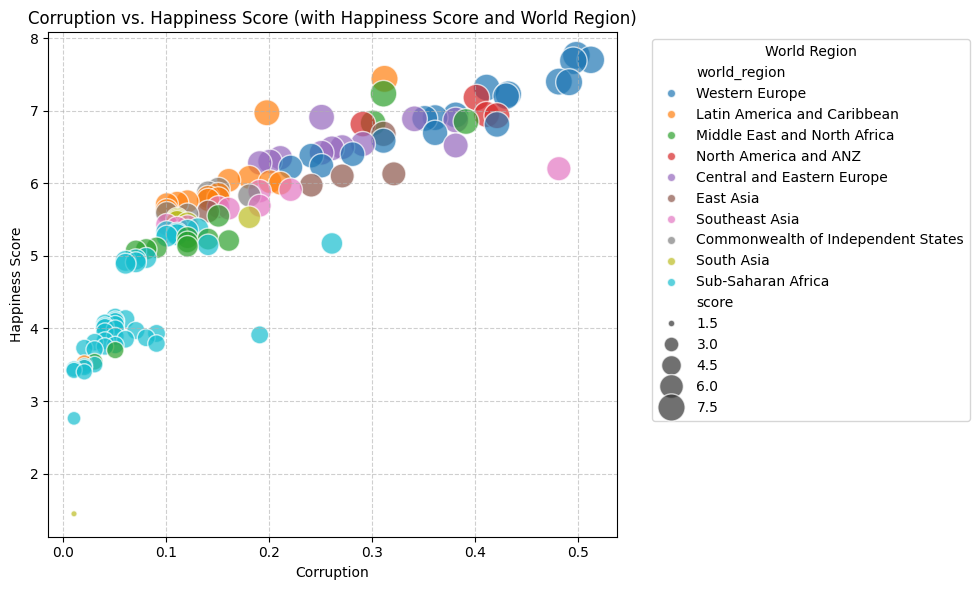

In [12]:
# Calculate the correlation matrix for numerical columns
numerical_cols = ['score', 'gdp', 'support', 'life_ex', 'freedom', 'generosity', 'corruption']
correlation_matrix = happy_df[numerical_cols].corr()

# Get features correlated with 'score' (excluding 'score' itself)
correlated_features = correlation_matrix['score'].drop('score').index.tolist()

for feature in correlated_features:
    correlation_value = correlation_matrix.loc['score', feature]
    print(f"Correlation between 'score' and '{feature}': {correlation_value:.2f}")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=happy_df, x=feature, y='score', hue='world_region', size='score', sizes=(20, 400), alpha=0.7)
    plt.title(f'{feature.replace("_", " ").title()} vs. Happiness Score (with Happiness Score and World Region)')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Happiness Score')
    plt.legend(title='World Region', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

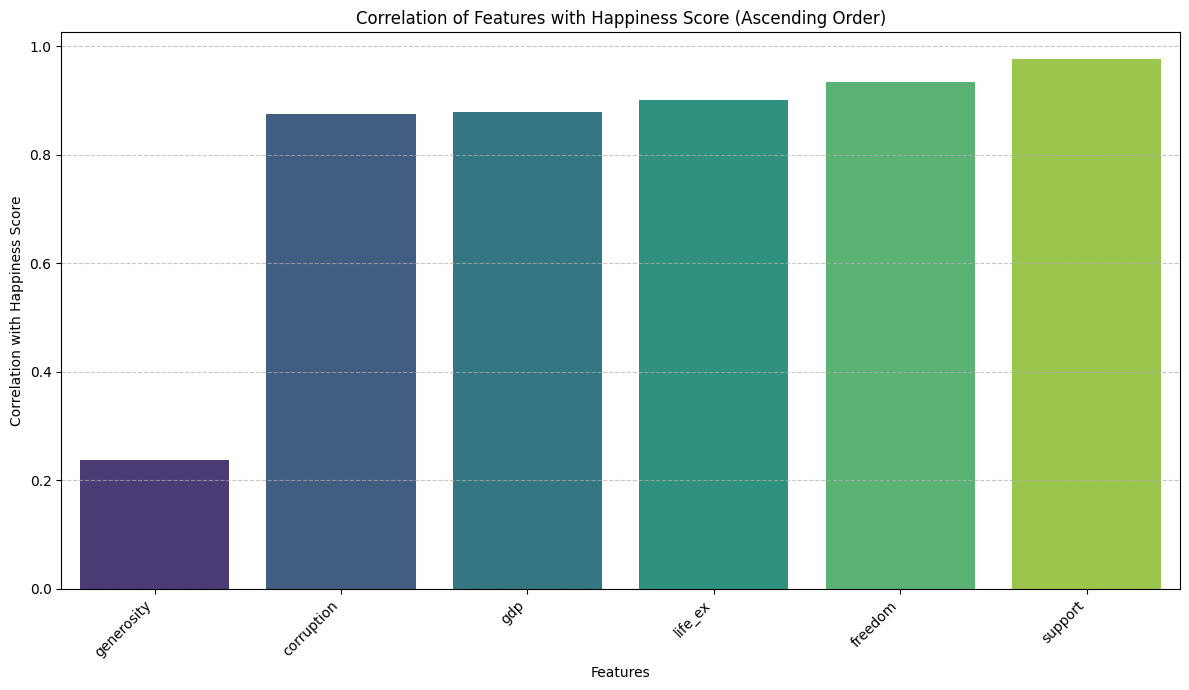

In [13]:
# Calculate correlations with 'score'
correlations = happy_df[numerical_cols].corr()['score'].drop('score')

# Sort correlations in ascending order
sorted_correlations = correlations.sort_values(ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_correlations.index, y=sorted_correlations.values, palette='viridis')
plt.title('Correlation of Features with Happiness Score (Ascending Order)')
plt.xlabel('Features')
plt.ylabel('Correlation with Happiness Score')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Distribution of 'social_support' and 'score'

Let's visualize the distribution of 'social_support' and 'score' and check their skewness to understand their normality.

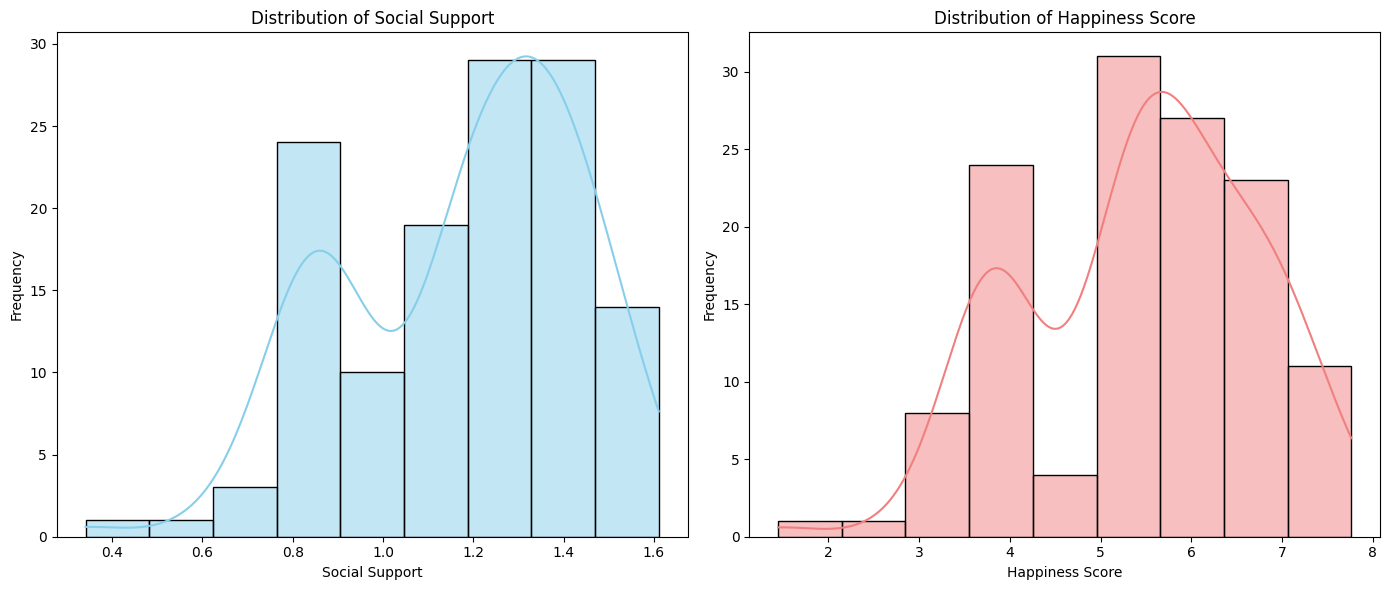

In [14]:
plt.figure(figsize=(14, 6))

# Distribution of 'social_support'
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(happy_df['support'], kde=True, color='skyblue')
plt.title('Distribution of Social Support')
plt.xlabel('Social Support')
plt.ylabel('Frequency')

# Distribution of 'score'
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(happy_df['score'], kde=True, color='lightcoral')
plt.title('Distribution of Happiness Score')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Skewness Calculation

Now, let's calculate the skewness for both 'social_support' and 'score' to quantify the asymmetry of their distributions.

In [15]:
from scipy.stats import skew

skewness_support = skew(happy_df['support'])
skewness_score = skew(happy_df['score'])

print(f"Skewness for 'Social Support': {skewness_support:.2f}")
print(f"Skewness for 'Happiness Score': {skewness_score:.2f}")

if abs(skewness_support) < 0.5: # A common rule of thumb for low skewness
    print("\n'Social Support' distribution is relatively symmetric.")
elif skewness_support > 0:
    print("\n'Social Support' distribution is positively skewed (right-skewed).")
else:
    print("\n'Social Support' distribution is negatively skewed (left-skewed).")

if abs(skewness_score) < 0.5:
    print("'Happiness Score' distribution is relatively symmetric.")
elif skewness_score > 0:
    print("'Happiness Score' distribution is positively skewed (right-skewed).")
else:
    print("'Happiness Score' distribution is negatively skewed (left-skewed).")

Skewness for 'Social Support': -0.54
Skewness for 'Happiness Score': -0.37

'Social Support' distribution is negatively skewed (left-skewed).
'Happiness Score' distribution is relatively symmetric.


### Boxplot de 'score' por 'world_region'

Vamos a visualizar la distribución de la puntuación de felicidad ('score') para cada región del mundo utilizando un diagrama de caja (boxplot). Esto nos ayudará a entender la dispersión y las tendencias centrales de la felicidad en cada región.

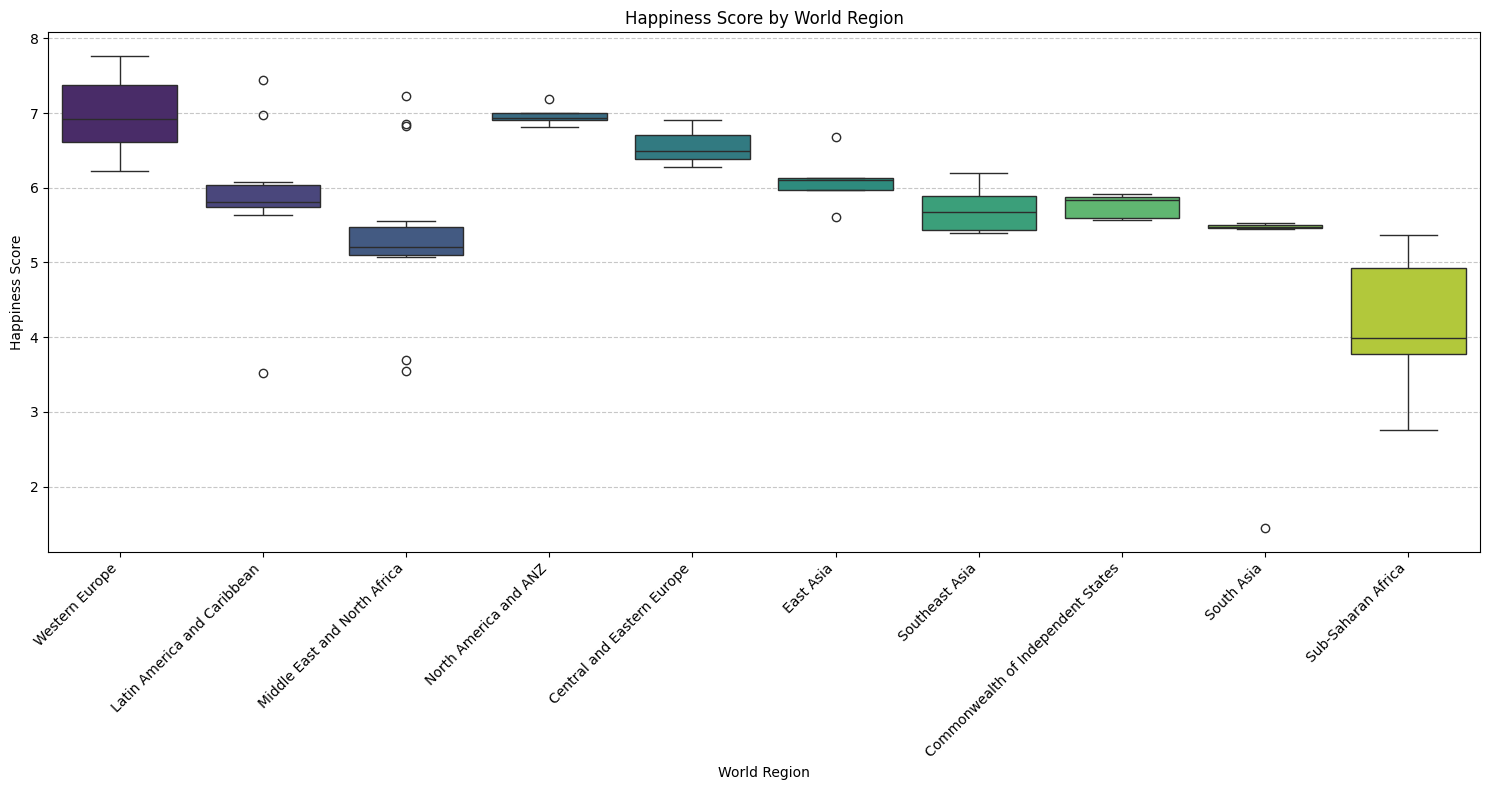

In [16]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='world_region', y='score', data=happy_df, palette='viridis')
plt.title('Happiness Score by World Region')
plt.xlabel('World Region')
plt.ylabel('Happiness Score')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Boxplot de 'social_support' por 'world_region'

Ahora, visualicemos la distribución del apoyo social ('social_support') para cada región del mundo. Esto nos ayudará a identificar cómo varía el apoyo social regionalmente.

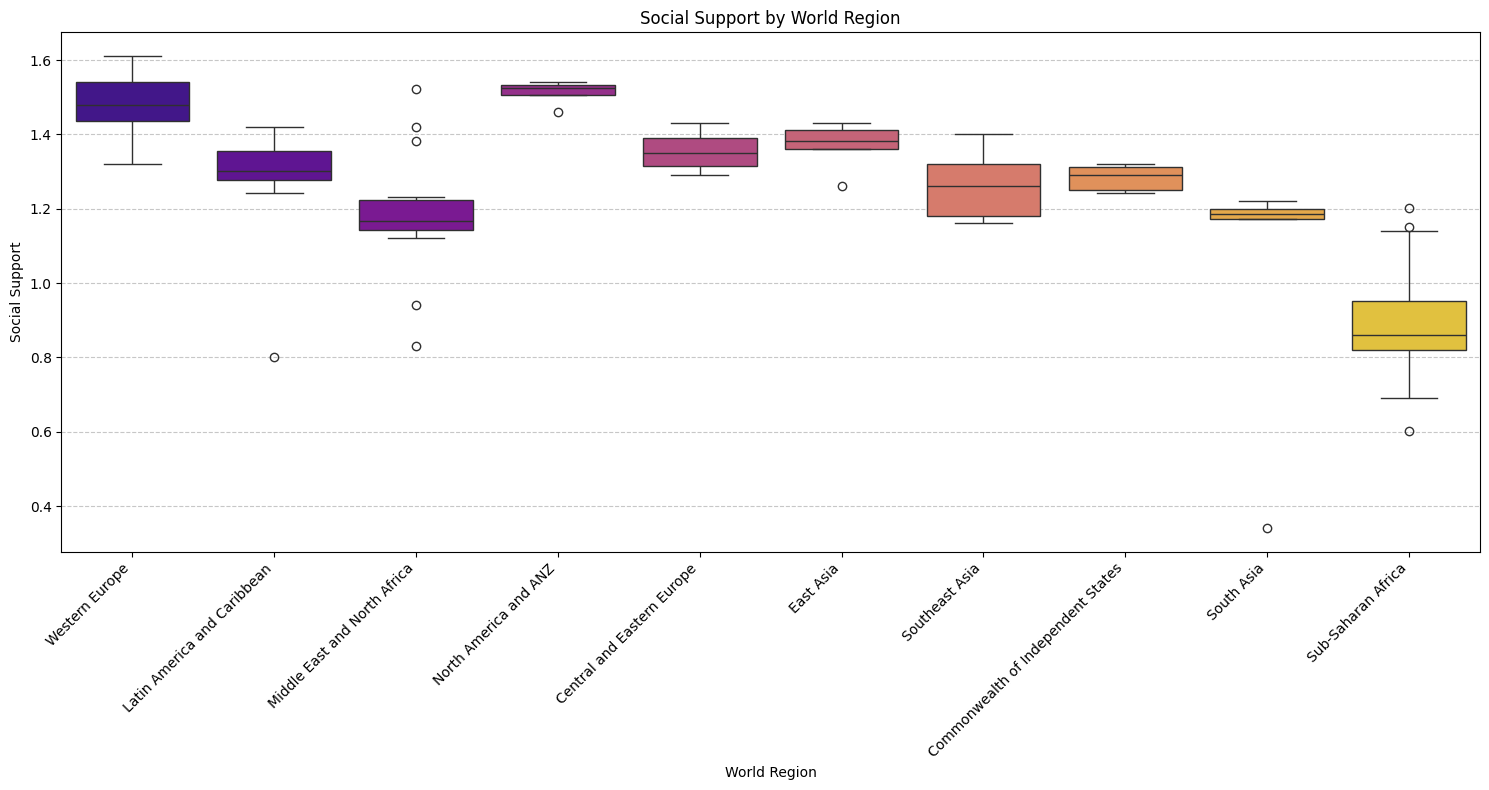

In [17]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='world_region', y='support', data=happy_df, palette='plasma')
plt.title('Social Support by World Region')
plt.xlabel('World Region')
plt.ylabel('Social Support')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Boxplot de 'freedom' por 'world_region'

Finalmente, vamos a visualizar la distribución de 'freedom' (libertad) para cada región del mundo. Esto nos permitirá ver las diferencias regionales en este importante factor de felicidad.

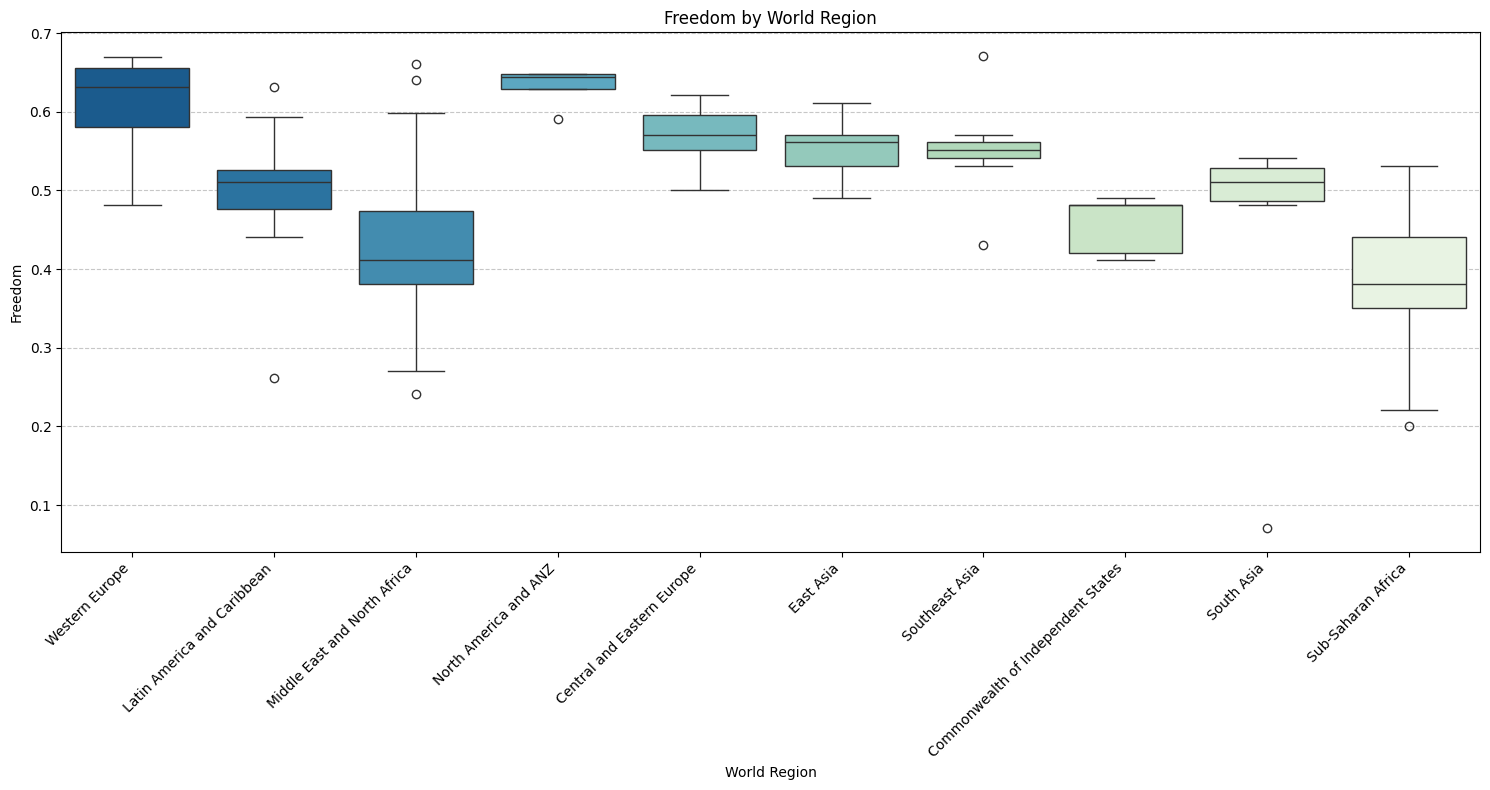

In [18]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='world_region', y='freedom', data=happy_df, palette='GnBu_r')
plt.title('Freedom by World Region')
plt.xlabel('World Region')
plt.ylabel('Freedom')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Puntuación de Felicidad en Europa Occidental

Vamos a filtrar el DataFrame para mostrar solo los países de la región 'Western Europe' y visualizar sus puntuaciones de felicidad en un gráfico de barras.

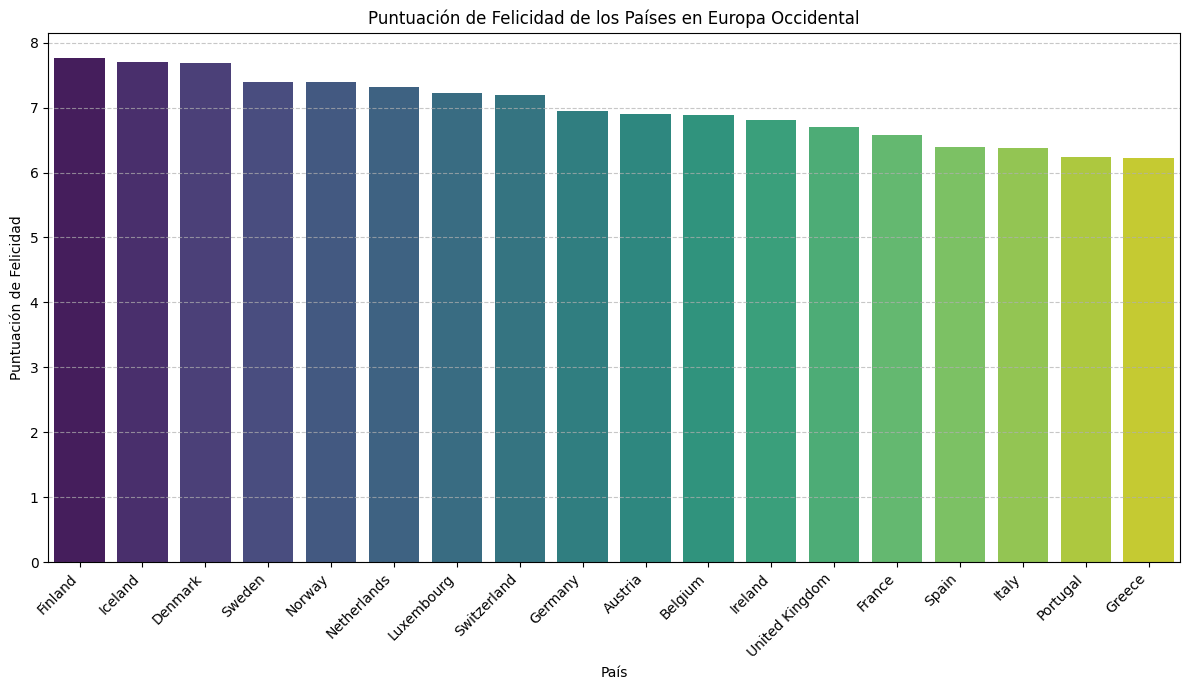

In [19]:
# Filtrar los datos para la región de 'Western Europe'
western_europe_df = happy_df[happy_df['world_region'] == 'Western Europe'].sort_values(by='score', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='country', y='score', data=western_europe_df, palette='viridis')
plt.title('Puntuación de Felicidad de los Países en Europa Occidental')
plt.xlabel('País')
plt.ylabel('Puntuación de Felicidad')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [20]:
print('Descriptive Statistics for Western Europe:')
display(western_europe_df.describe())

Descriptive Statistics for Western Europe:


,rank,score,gdp,support,life_ex,freedom,generosity,corruption
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,17.333333,6.987167,1.863944,1.479389,0.945222,0.613000,0.187167,0.385000
std,12.938770,0.503135,0.117717,0.077189,0.010647,0.056379,0.060862,0.094514
min,1.000000,6.221000,1.601000,1.321000,0.921000,0.481000,0.091000,0.221000
25%,6.250000,6.613000,1.828500,1.436000,0.941000,0.581000,0.133500,0.321000
50%,15.500000,6.923000,1.876500,1.479500,0.944500,0.631000,0.183500,0.396000
75%,26.500000,7.373750,1.890750,1.541000,0.952000,0.655750,0.223250,0.468750
max,39.000000,7.764000,2.096000,1.611000,0.961000,0.670000,0.271000,0.512000


### Visualizing Outliers with Boxplots

Boxplots are an excellent way to visually identify outliers. Let's create boxplots for each numerical feature to see if the detected outliers are visible.

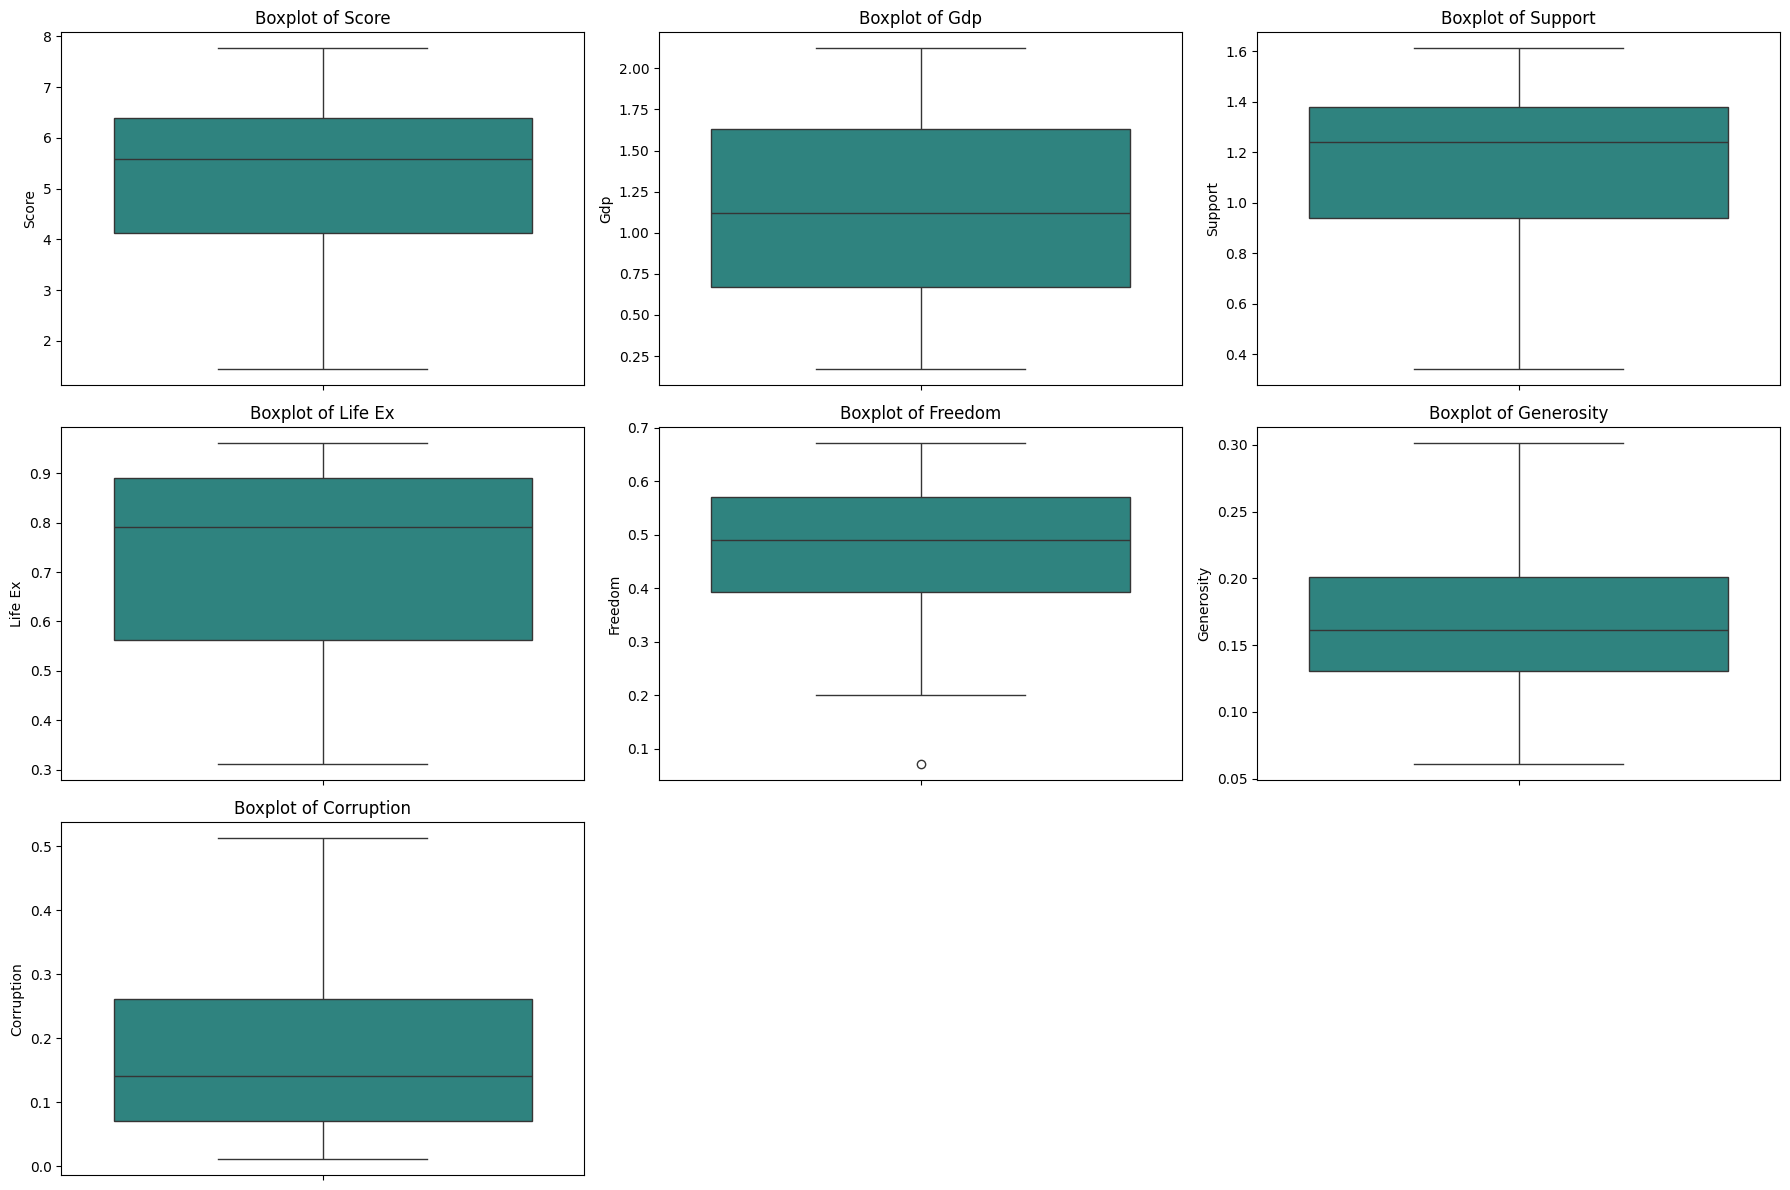

In [42]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=happy_df[col], palette='viridis')
    plt.title(f'Boxplot of {col.replace("_", " ").title()}')
    plt.ylabel(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

### Visualización de la Matriz de Correlación con un Heatmap

Vamos a generar una matriz de correlación visual de las variables numéricas y mostrarla como un mapa de calor (heatmap). Esto nos ayudará a entender las relaciones entre las variables de un vistazo.

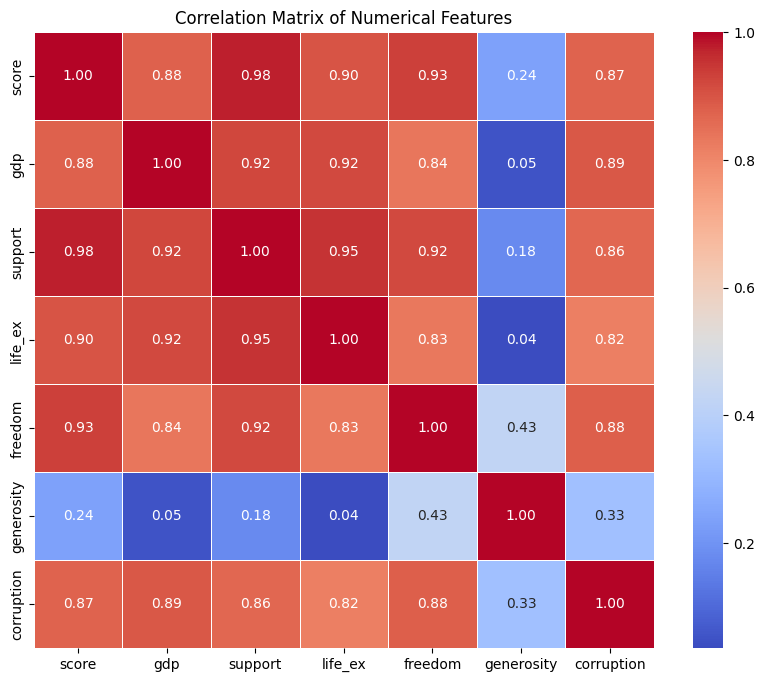

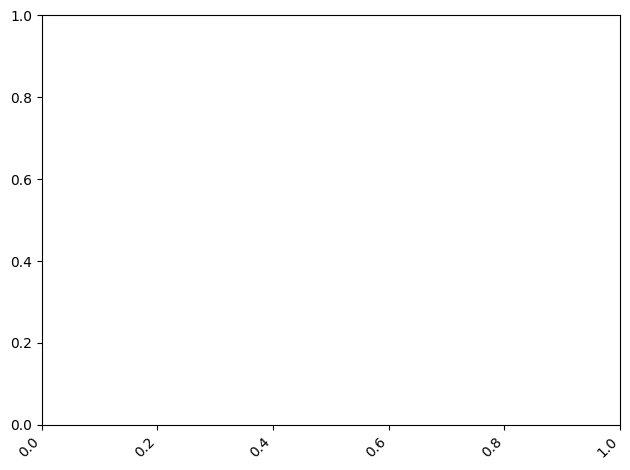

In [21]:
# Calculate the correlation matrix for numerical columns
correlation_matrix_all = happy_df[numerical_cols_for_outliers].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Regresión Lineal Simple: 'Social Support' vs. 'Score'

Ahora, realizaremos un análisis de regresión lineal simple para modelar la relación entre 'social_support' y 'score'. Luego, visualizaremos la recta de regresión ajustada en un diagrama de dispersión.

In [22]:
# Seleccionar la característica (X) y la variable objetivo (y)
X = happy_df[['support']]
y = happy_df['score']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo de regresión lineal
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

print("Modelo de Regresión Lineal Entrenado.")
print(f"Coeficiente (pendiente): {model.coef_[0]:.2f}")
print(f"Intercepción: {model.intercept_:.2f}")

Modelo de Regresión Lineal Entrenado.
Coeficiente (pendiente): 4.74
Intercepción: -0.13


### Visualización de la Recta de Regresión Ajustada

Visualicemos los datos de prueba y la recta de regresión lineal ajustada para entender la relación entre 'social_support' y 'score'.

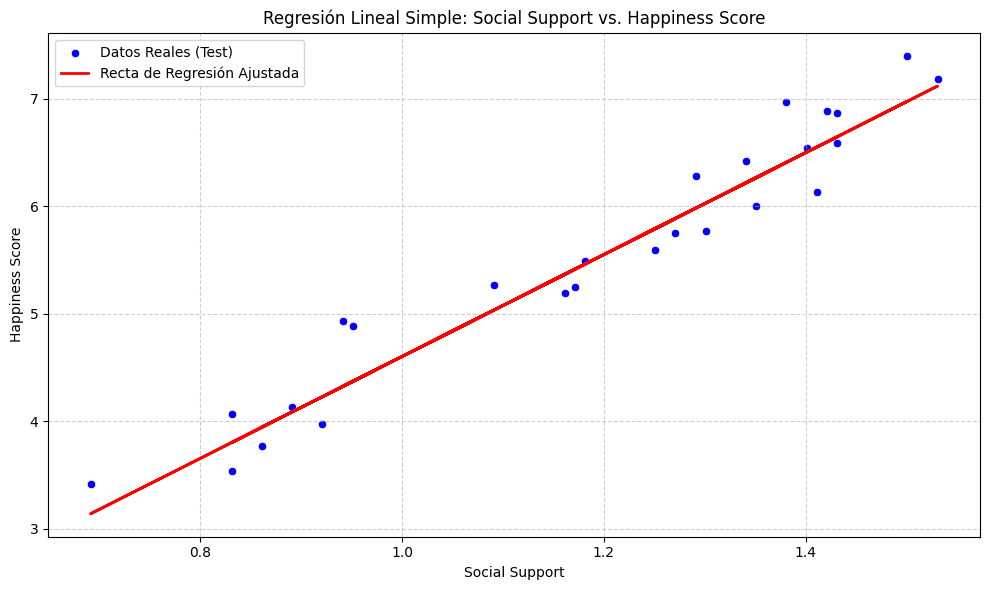

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['support'], y=y_test, color='blue', label='Datos Reales (Test)')
plt.plot(X_test['support'], y_pred, color='red', linewidth=2, label='Recta de Regresión Ajustada')
plt.title('Regresión Lineal Simple: Social Support vs. Happiness Score')
plt.xlabel('Social Support')
plt.ylabel('Happiness Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

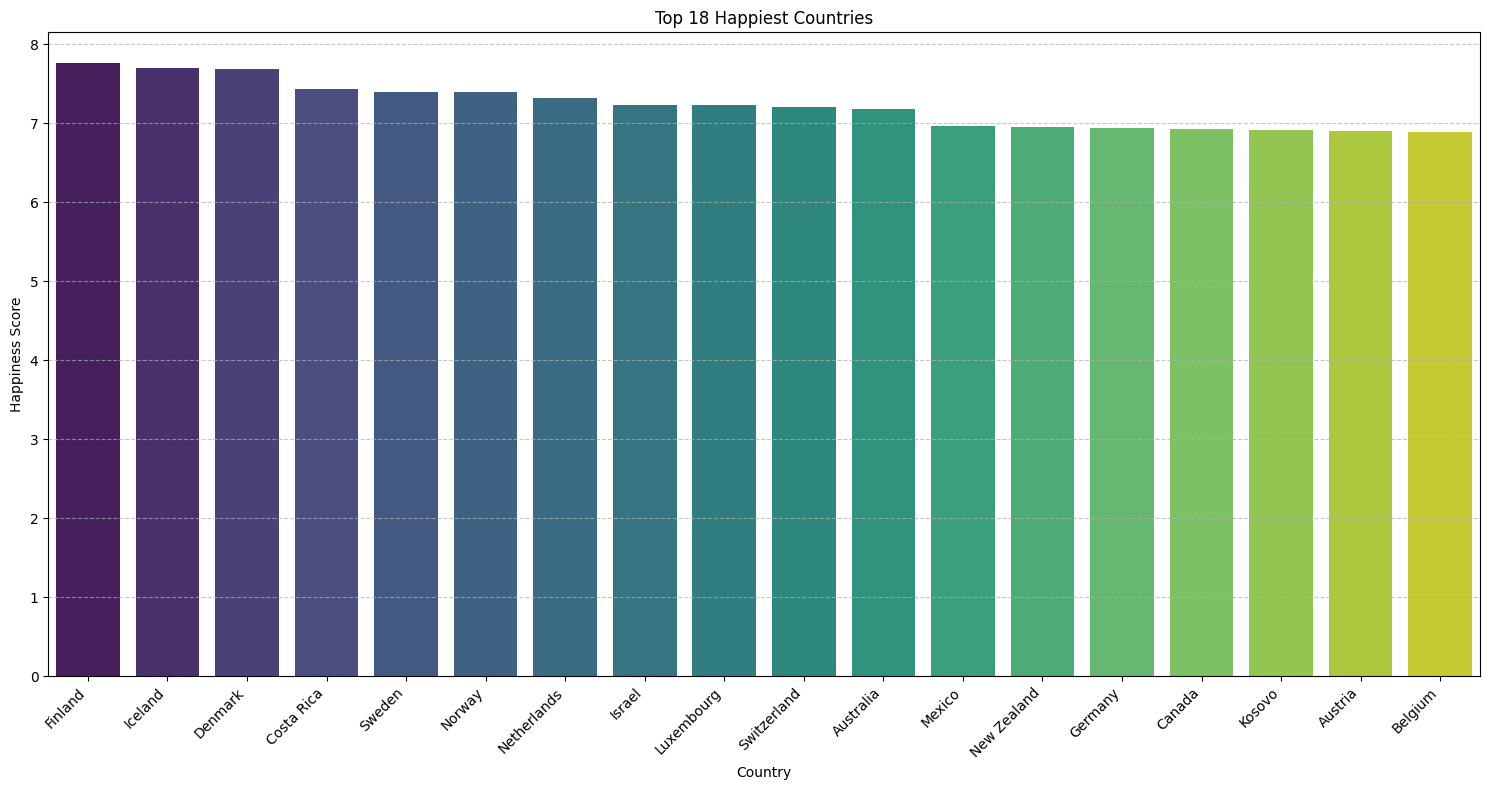

In [24]:
happiest_countries = happy_df.sort_values(by='score', ascending=False).head(18)

plt.figure(figsize=(15, 8))
sns.barplot(x='country', y='score', data=happiest_countries, palette='viridis')
plt.title('Top 18 Happiest Countries')
plt.xlabel('Country')
plt.ylabel('Happiness Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [50]:
#@title Predicción de Happiness Score basado en Social Support

# Introduce un valor para 'social_support'
# El valor debe estar dentro del rango observado en los datos (aproximadamente 0.34 a 1.61)
support_value = 1.0 #@param {type:"number"}

# Asegúrate de que el input tenga el formato correcto para el modelo (DataFrame 2D)
input_data = pd.DataFrame({'support': [support_value]})

# Realiza la predicción
predicted_score = model.predict(input_data)

print(f"Para un valor de 'Social Support' de {support_value:.2f}, el 'Happiness Score' predicho es: {predicted_score[0]:.2f}")

Para un valor de 'Social Support' de 1.00, el 'Happiness Score' predicho es: 4.60


In [25]:
western_europe_countries = set(western_europe_df['country'])
happiest_18_countries = set(happiest_countries['country'])

common_countries = list(western_europe_countries.intersection(happiest_18_countries))

print(f"Western Europe among the most happy countries: {len(common_countries)}")
print("Western Europe countries in Top 18:")
for country in common_countries:
    print(f"- {country}")

Western Europe among the most happy countries: 11
Western Europe countries in Top 18:
- Finland
- Austria
- Norway
- Denmark
- Sweden
- Luxembourg
- Germany
- Switzerland
- Netherlands
- Iceland
- Belgium


In [26]:
# Filtrar happy_df para incluir solo los países comunes
common_countries_df = happy_df[happy_df['country'].isin(common_countries)]

# Calcular la correlación entre 'support' y 'freedom' para estos países
correlation_support_freedom_common = common_countries_df['support'].corr(common_countries_df['freedom'])

print(f"Correlación entre 'Social Support' y 'Freedom' para los 11 países de Europa Occidental en el Top 18: {correlation_support_freedom_common:.2f}")

Correlación entre 'Social Support' y 'Freedom' para los 11 países de Europa Occidental en el Top 18: 0.86


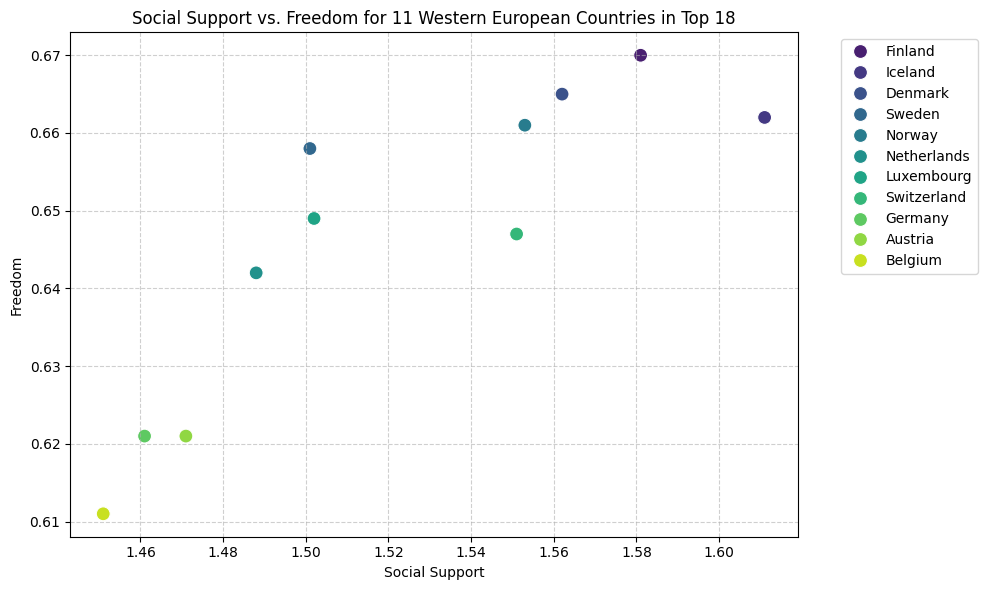

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='support', y='freedom', data=common_countries_df, hue='country', s=100, palette='viridis')
plt.title('Social Support vs. Freedom for 11 Western European Countries in Top 18')
plt.xlabel('Social Support')
plt.ylabel('Freedom')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()